In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, binom, uniform, norm

In [2]:
plt.rcParams.update({'font.size': 20})  # 전역 폰트 크기를 20로 설정

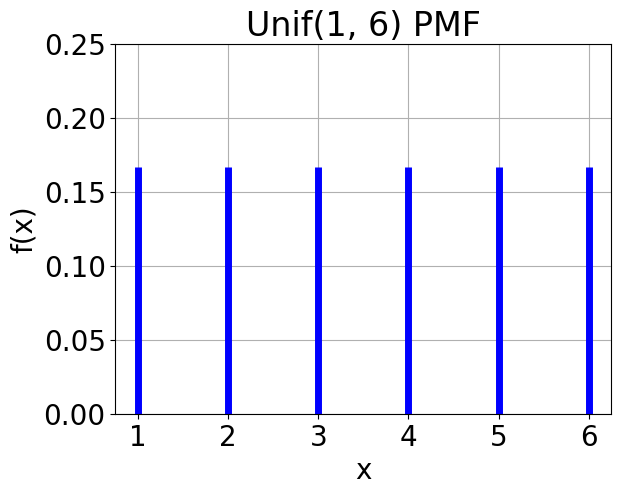

In [3]:
# 이산균등분포 PMF
fig, ax = plt.subplots()

# 분포 파라미터 설정 (예: 1부터 6까지의 값)
a, b = 1, 6

x = np.arange(a, b + 1)

rv = randint(a, b + 1)  # b + 1 이유: scipy의 randint는 상한이 제외됨
pmf_du = rv.pmf(x)

ax.vlines(x, 0, pmf_du, colors='b', lw=5)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(f'Unif({a}, {b}) PMF')
ax.set_xticks(x)
ax.set_ylim(0, 0.25)
plt.grid(True)
plt.show()

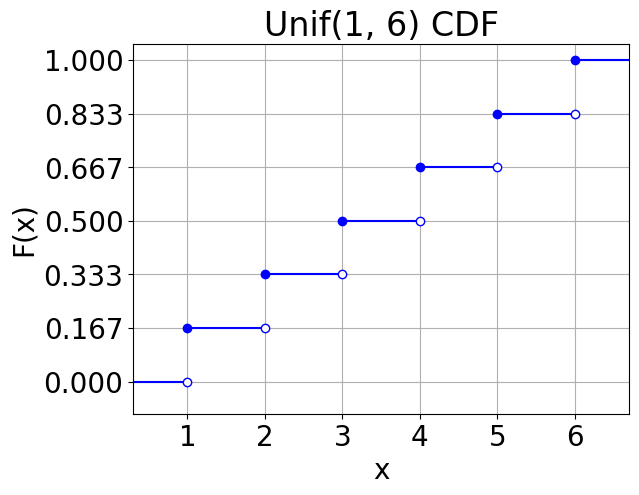

In [4]:
# 이산균등분포 CDF
x = np.arange(a - 1, b + 2)  # x quantile값 재조정
rv = randint(a, b + 1)  # randint에서 상한은 포함되지 않으므로 +1
cdf_vals = rv.cdf(x)  # 좌측 누적 확률 값 (CDF)

# 각 구간의 수평선을 그리기 위한 좌표 계산
x_start = x[:-1]
x_end = x[1:]
y_vals = cdf_vals[:-1]

# 그래프 그리기
fig, ax = plt.subplots()

# 수평선 그리기
for xs, xe, y in zip(x_start, x_end, y_vals):
    ax.hlines(y, xs, xe, colors='b')
# 마지막 수평선 추가 (최대값까지)
ax.hlines(cdf_vals[-1], x[-1], x[-1] + 1, colors='b')

# 닫힌 동그라미 (●) 표시 - 각 구간의 시작점
ax.plot(x[:-1], y_vals, 'bo')
# 열린 동그라미 (○) 표시 - 각 구간의 끝점
ax.plot(x[1:], y_vals, 'bo', mfc='white')

# 그래프 설정
ax.set_xlabel('x')
ax.set_ylabel('F(x)')
ax.set_title(f'Unif({a}, {b}) CDF')
ax.set_xticks(np.arange(a-1, b+2))
ax.set_yticks(np.linspace(0, 1, b - a + 2))
ax.set_xlim(a - 0.7, b + 0.7)
ax.set_ylim(-0.1, 1.05)
ax.grid(True)
plt.show()

In [5]:
a, b = 1, 6
rv = randint(a, b + 1)  # randint에서 상한은 포함되지 않으므로 +1

# 1) 확률 변수의 실현 값 (랜덤 샘플 생성). rvs: Random Variates
print(rv.rvs(size=10))

# 2) 좌측 누적 확률이 주어졌을 때 quantile 값. ppf: percent point function
print(rv.ppf(0.1667))

# 3) quantile 값이 주어졌을 때, 좌측 누적 확률 값 (CDF)
print(rv.cdf(2))

# 4) PMF 값 (y값)
print(rv.pmf(2))

[3 4 5 5 4 1 4 1 4 5]
2.0
0.3333333333333333
0.16666666666666666


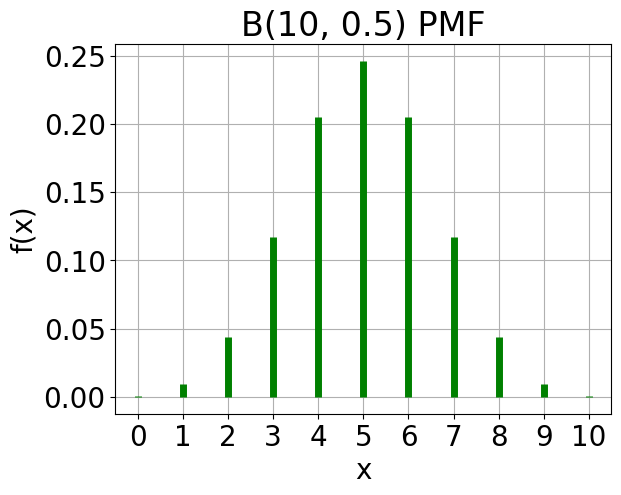

In [6]:
# 이항분포 PMF
fig, ax = plt.subplots()

n, p = 10, 0.5  # 시행 횟수 n, 성공 확률 p
x = np.arange(0, n + 1)
rv = binom(n, p)
pmf_binom = rv.pmf(x)

ax.vlines(x, 0, pmf_binom, colors='g', lw=5)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_xticks(np.arange(0, n + 1))
ax.set_title(f'B({n}, {p}) PMF')
plt.grid(True)
plt.show()

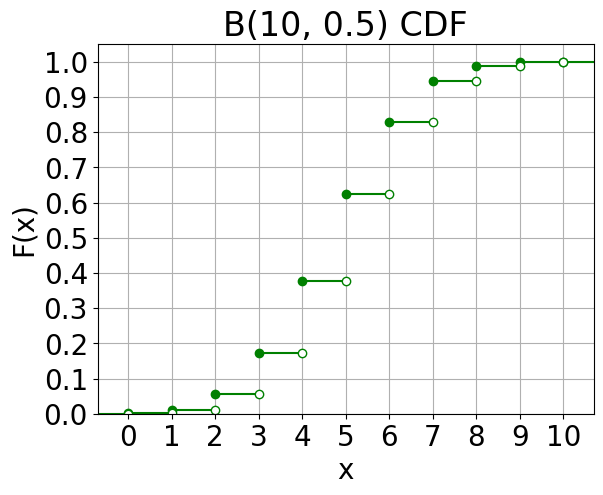

In [7]:
# 이항분포 CDF
x = np.arange(-1, n + 2)   # x quantile값 재조정
# 좌측 누적 확률 값 (CDF)
cdf_vals = rv.cdf(x)

# 그래프 그리기
fig, ax = plt.subplots()

# 각 구간의 수평선을 그리기 위한 좌표 계산
x_start = x[:-1]
x_end = x[1:]
y_vals = cdf_vals[:-1]

# 수평선 그리기
for xs, xe, y in zip(x_start, x_end, y_vals):
    ax.hlines(y, xs, xe, colors='g')
# 마지막 수평선 추가 (최대값까지)
ax.hlines(cdf_vals[-1], x[-1], x[-1] + 1, colors='g')

# 닫힌 동그라미 (●) 표시 - 각 구간의 시작점
ax.plot(x[:-1], y_vals, 'go')
# 열린 동그라미 (○) 표시 - 각 구간의 끝점
ax.plot(x[1:], y_vals, 'go', mfc='white')

# 그래프 설정
ax.set_xlabel('x')
ax.set_ylabel('F(x)')
ax.set_title(f'B({n}, {p}) CDF')
ax.set_xticks(np.arange(0, n + 2))
ax.set_yticks(np.linspace(0, 1, n + 1))
ax.set_xlim(-0.7, n + 0.7)
ax.set_ylim(0, 1.05)
ax.grid(True)
plt.show()

In [8]:
n, p = 10, 0.5  # 시행 횟수 n, 성공 확률 p
rv = binom(n, p)

# 1) 확률 변수의 실현 값 (랜덤 샘플 생성)
print(rv.rvs(size=10))

# 2) 좌측 누적 확률이 주어졌을 때 quantile 값. ppf:percent point function
print(rv.ppf(0.2))

# 3) quantile 값이 주어졌을 때, 좌측 누적 확률 값 (CDF)
print(rv.cdf(4))

# 4) PMF 값 (y값)
print(rv.pmf(4))

[5 6 6 3 5 7 3 6 7 3]
4.0
0.376953125
0.2050781249999999


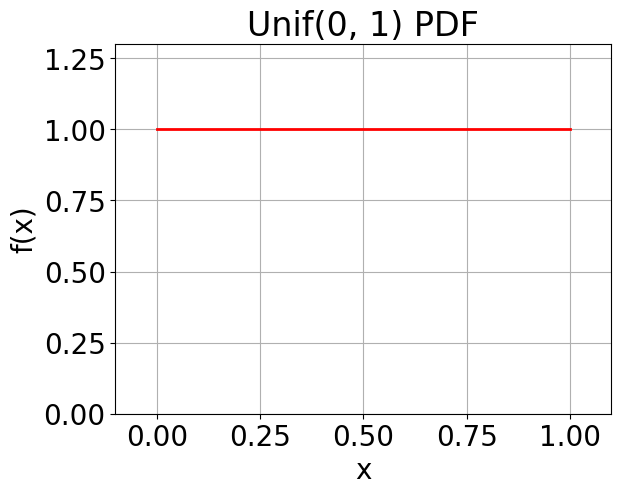

In [9]:
# 연속균등분포 PDF
fig, ax = plt.subplots()

a, b = 0, 1  # 구간 [a, b]
rv = uniform(loc=a, scale=b - a)

x = np.linspace(a, b, 1000)

pdf_uniform = rv.pdf(x)

ax.plot(x, pdf_uniform, 'r', lw=2)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(f'Unif({a}, {b}) PDF')
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(0, 1.3)
plt.grid(True)
plt.show()

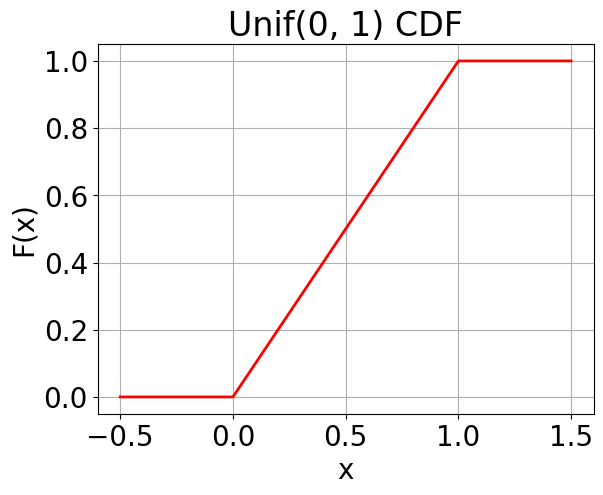

In [10]:
# 연속균등분포 CDF
x = np.linspace(a-0.5, b+0.5, 1000)  # x값 재조정
cdf_vals = rv.cdf(x)

# 그래프 그리기
fig, ax = plt.subplots()

# CDF 그래프
ax.plot(x, cdf_vals, 'r', lw=2)
ax.set_xlabel('x')
ax.set_ylabel('F(x)')
ax.set_title(f'Unif({a}, {b}) CDF')
ax.grid(True)
plt.show()

In [11]:
a, b = 0, 1  # 구간 [a, b]
rv = uniform(loc=a, scale=b - a)

# 1) 확률 변수의 실현 값 (랜덤 샘플 생성)
print(rv.rvs(size=10))

# 2) 좌측 누적 확률이 주어졌을 때 quantile 값. ppf:percent point function
print(rv.ppf(0.2))

# 3) quantile 값이 주어졌을 때, 좌측 누적 확률 값 (CDF)
print(rv.cdf(0.2))

# 4) PMF 값 (y값)
print(rv.pdf(0.5))

[0.55920839 0.17067795 0.09987062 0.30102641 0.94824901 0.74509937
 0.08002938 0.86283253 0.75057486 0.27701841]
0.2
0.2
1.0


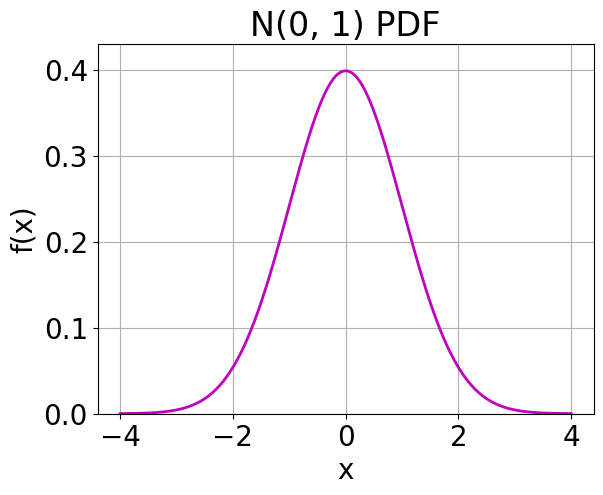

In [12]:
# 정규분포 PDF
fig, ax = plt.subplots()

mu, sigma = 0, 1  # 평균과 표준편차
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
rv = norm(loc=mu, scale=sigma)
pdf_norm = rv.pdf(x)

ax.plot(x, pdf_norm, 'm', lw=2)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(f'N({mu}, {sigma}) PDF')
ax.set_ylim(0, 0.43)
plt.grid(True)
plt.show()

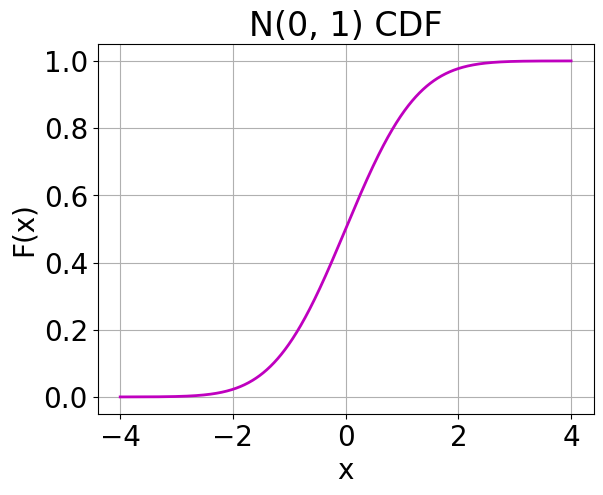

In [13]:
# 4. 정규분포 CDF
cdf_vals = rv.cdf(x)

# 그래프 그리기
fig, ax = plt.subplots()

# CDF 그래프
ax.plot(x, cdf_vals, 'm', lw=2)
ax.set_xlabel('x')
ax.set_ylabel('F(x)')
ax.set_title(f'N({mu}, {sigma}) CDF')
ax.grid(True)
plt.show()

In [14]:
mu, sigma = 0, 1
rv = norm(loc=mu, scale=sigma)

# 1) 확률 변수의 실현 값 (랜덤 샘플 생성)
print(rv.rvs(size=10))

# 2) 좌측 누적 확률이 주어졌을 때 quantile 값. ppf:percent point function
print(rv.ppf(0.025))

# 3) quantile 값이 주어졌을 때, 좌측 누적 확률 값 (CDF)
print(rv.cdf(1.96))

# 4) PMF 값 (y값)
print(rv.pdf(0))

[-0.17070068 -0.58978682 -0.39701244  0.63352451 -1.21922982  1.27691924
 -0.07434823 -0.50236748 -1.02956429 -0.04247306]
-1.9599639845400545
0.9750021048517795
0.3989422804014327


In [15]:
1/np.sqrt(2*np.pi)

np.float64(0.3989422804014327)

In [16]:
mu, sigma = 0, 1
rv = norm(loc=mu, scale=sigma)

print(rv.rvs())
print(rv.rvs(size=3))

0.4031172367733802
[-1.27946186 -0.70606071 -0.96667276]


In [17]:
n, p = 10, 0.5
rv = binom(n, p)

print(rv.rvs())
print(rv.rvs(size=10))

6
[3 3 6 7 3 8 7 4 5 7]


In [18]:
mu, sigma = 0, 1
rv = norm(loc=mu, scale=sigma)

print(rv.ppf([0.5]))
print(rv.ppf([0.025,0.975]))

[0.]
[-1.95996398  1.95996398]


In [19]:
a, b = 1, 6
rv = randint(a, b + 1)

print(rv.ppf(0.1666))
print(rv.ppf(0.1667))

1.0
2.0


In [20]:
mu, sigma = 0, 1
rv = norm(loc=mu, scale=sigma)

print(rv.cdf(0))
print(rv.cdf([-1.96,1.96]))

0.5
[0.0249979 0.9750021]


In [21]:
a, b = 1, 6
rv = randint(a, b + 1)

print(rv.cdf(1.9))
print(rv.cdf(2))

0.16666666666666666
0.3333333333333333


In [22]:
a, b = 1, 6
rv = randint(a, b + 1)

print(rv.pmf(1))
print(rv.pmf([1, 2, 3.5]))

0.16666666666666666
[0.16666667 0.16666667 0.        ]


In [23]:
mu, sigma = 0, 1
rv = norm(loc=mu, scale=sigma)

print(rv.pdf(5))
print(rv.pdf([-1, -0.5, 0, 0.5]))

1.4867195147342979e-06
[0.24197072 0.35206533 0.39894228 0.35206533]


In [3]:
# 두 주사위의 결합분포표
import pandas as pd

# 가능한 눈의 값
dice_values = np.arange(1, 7)

# 두 주사위의 가능한 모든 조합 생성
X, Y = np.meshgrid(dice_values, dice_values)

# 결합확률분포표 생성 (모든 조합의 확률은 1/36)
joint_prob = np.full((6, 6), '1/36')

# 판다스 데이터프레임으로 변환
df_joint_prob = pd.DataFrame(joint_prob, index=dice_values, columns=dice_values)

# 인덱스와 컬럼 이름 지정
df_joint_prob.index.name = 'X'
df_joint_prob.columns.name = 'Y'

# 결합분포표 출력
print("두 주사위(X,Y)의 결합확률분포표:")
df_joint_prob

두 주사위(X,Y)의 결합확률분포표:


Y,1,2,3,4,5,6
X,,,,,,
1,1/36,1/36,1/36,1/36,1/36,1/36
2,1/36,1/36,1/36,1/36,1/36,1/36
3,1/36,1/36,1/36,1/36,1/36,1/36
4,1/36,1/36,1/36,1/36,1/36,1/36
5,1/36,1/36,1/36,1/36,1/36,1/36
6,1/36,1/36,1/36,1/36,1/36,1/36


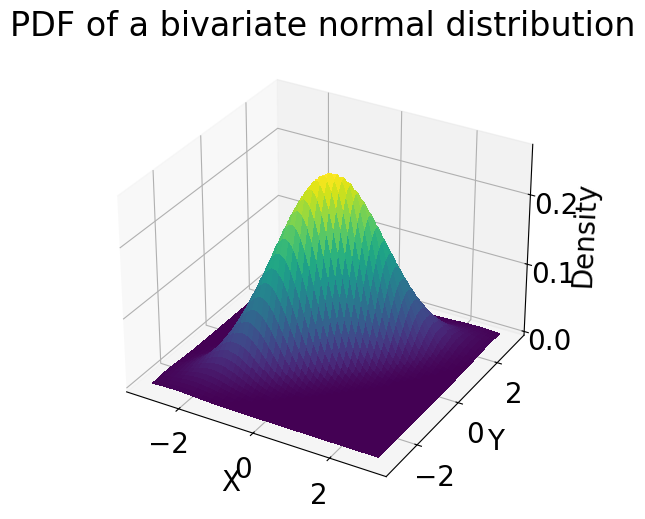

In [37]:
# 이변량 정규분포의 결합확률분포

from scipy.stats import multivariate_normal

# 평균 벡터와 공분산 행렬 설정
mu = [0, 0]
sigma = [[1, 0.8], [0.8, 1]]  # 상관계수 0.8

# 좌표 생성
x = np.linspace(-3, 3, 500)
y = np.linspace(-3, 3, 500)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

# 이변량 정규분포 생성
rv = multivariate_normal(mu, sigma)
Z = rv.pdf(pos)

# 3D 그래프로 PDF 그리기
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))

# 3D 표면 플롯
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=False)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Density')
ax.set_title('PDF of a bivariate normal distribution')

plt.show()